# Ricci Finance V15 Final Lecture
## No TensorFlow · No POT · SciPy-LP Ollivier-Ricci · Forman-Ricci · HMM · PyTorch GNN

This notebook uses the exact same package modules as `app.py`.

## 1. Architecture

`market data → rolling graphs → curvature → graph features → HMM labels → GNN comparison`

- **Ollivier LP** solves discrete optimal transport with SciPy HiGHS.
- **Forman** provides a much faster curvature proxy.
- Both save results under `ricciCurvature`.

In [1]:
import sys, importlib.util
print("Python", sys.version)
for forbidden in ["tensorflow", "ot", "GraphRicciCurvature"]:
    print(forbidden, "installed:", importlib.util.find_spec(forbidden) is not None)

Python 3.14.2 (main, Jan  2 2026, 14:27:39) [GCC 15.2.1 20251112]
tensorflow installed: True
ot installed: True
GraphRicciCurvature installed: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from ricci_finance.data import prepare_market_data
from ricci_finance.pipeline import build_rolling_frames
from ricci_finance.hmm import DEFAULT_HMM_FEATURES, fit_gaussian_hmm, build_regime_labels
from ricci_finance.sectors import assign_sectors
from ricci_finance.gnn import train_gcn_regime

## 2. Download market data

Change the tickers or period as needed.

In [4]:
TICKERS = ["NVDA", "AMD", "AVGO", "ANET", "MRVL", "MU", "LRCX", "KLAC"]
market = prepare_market_data(TICKERS, period="5y")
close = market["close"]
returns = market["returns"]
dollar_volume = market["dollar_volume"]
close.tail(2)

Ticker,AMD,ANET,AVGO,KLAC,LRCX,MRVL,MU,NVDA
Date,,,,,,,,
2026-07-22,552.330017,174.869995,396.809998,214.690002,319.290009,210.990005,959.479980,212.059998
2026-07-23,539.690002,176.610001,392.470001,218.729996,319.779999,209.320007,990.210022,208.759995


## 3. Fast Forman rolling graphs

Use this mode first to validate the full workflow quickly.

In [6]:
frames_forman, features_forman = build_rolling_frames(
    returns,
    dollar_volume,
    window=63,
    step=5,
    max_frames=50,
    k=4,
    min_corr=0.2,
    curvature_engine="forman",
)
features_forman.tail(2).T

,48,49
date,2026-07-16 00:00:00,2026-07-23 00:00:00
nodes,8,8
edges,22,22
density,0.785714,0.785714
avg_degree,5.5,5.5
avg_ricci,-7.467424,-7.473047
std_ricci,0.888091,0.882998
negative_edge_ratio,1.0,1.0
avg_abs_correlation,0.598698,0.605473
components,1,1


## 4. SciPy-LP Ollivier-Ricci example

For each edge, SciPy solves the transport plan between the two local probability measures. Begin with few frames because this is slower than Forman.

In [7]:
frames_ollivier, features_ollivier = build_rolling_frames(
    returns,
    dollar_volume,
    window=63,
    step=15,
    max_frames=8,
    k=4,
    min_corr=0.2,
    alpha=0.5,
    curvature_engine="ollivier_lp",
)
features_ollivier[["date", "avg_ricci", "negative_edge_ratio", "curvature_engine"]]

,date,avg_ricci,negative_edge_ratio,curvature_engine
0,2026-02-12,0.375957,0.0,ollivier_lp
1,2026-03-06,0.374402,0.0,ollivier_lp
2,2026-03-27,0.404445,0.0,ollivier_lp
3,2026-04-20,0.385912,0.0,ollivier_lp
4,2026-05-11,0.406005,0.0,ollivier_lp
5,2026-06-02,0.423408,0.0,ollivier_lp
6,2026-06-24,0.416580,0.0,ollivier_lp
7,2026-07-16,0.436222,0.0,ollivier_lp


## 5. Inspect edge curvature

In [8]:
latest = frames_ollivier[-1]["graph"]
edge_table = pd.DataFrame([
    {
        "source": u,
        "target": v,
        "correlation": d.get("correlation"),
        "distance": d.get("distance"),
        "wasserstein": d.get("wassersteinDistance"),
        "curvature": d.get("ricciCurvature"),
    }
    for u, v, d in latest.edges(data=True)
]).sort_values("curvature")
edge_table

,source,target,correlation,distance,wasserstein,curvature
8,ANET,KLAC,0.447416,1.051269,0.677139,0.354188
4,AMD,AVGO,0.586089,0.909847,0.560581,0.370345
10,AVGO,MU,0.586576,0.909312,0.551027,0.371954
9,ANET,LRCX,0.422546,1.074667,0.662004,0.382192
14,KLAC,MRVL,0.705512,0.767448,0.457760,0.397197
19,LRCX,NVDA,0.438625,1.059599,0.625830,0.401198
11,AVGO,LRCX,0.570143,0.927208,0.546519,0.404557
20,MRVL,MU,0.626228,0.864607,0.485802,0.416577
3,AMD,MRVL,0.610730,0.882350,0.502076,0.418135
16,KLAC,NVDA,0.484813,1.015073,0.575055,0.426104


## 6. Fit HMM regimes

`GaussianHMM` uses separate `fit()` and `predict()` calls inside the package. It does not call `fit_predict()`.

In [10]:
hmm = fit_gaussian_hmm(
    features_forman,
    list(DEFAULT_HMM_FEATURES),
    n_states=2,
    random_state=42,
)
aligned_frames = [frames_forman[i] for i in hmm.valid_index]
aligned_features = features_forman.iloc[hmm.valid_index].reset_index(drop=True).copy()
aligned_features["hmm_state"] = hmm.states
regime_names = build_regime_labels(aligned_features, hmm.states)
aligned_features["regime_name"] = [regime_names[int(s)] for s in hmm.states]
aligned_features.tail(2).T

,48,49
date,2026-07-16 00:00:00,2026-07-23 00:00:00
nodes,8,8
edges,22,22
density,0.785714,0.785714
avg_degree,5.5,5.5
avg_ricci,-7.467424,-7.473047
std_ricci,0.888091,0.882998
negative_edge_ratio,1.0,1.0
avg_abs_correlation,0.598698,0.605473
components,1,1


## 7. Train the pure-PyTorch GCN

The GNN receives graphs, HMM labels, and a ticker-to-sector dictionary. The graph and label lengths are guaranteed equal by `valid_index`.

In [11]:
sectors = assign_sectors(TICKERS)
gnn_result = train_gcn_regime(
    [frame["graph"] for frame in aligned_frames],
    hmm.states,
    sectors,
    epochs=150,
    hidden=24,
    random_state=42,
)
print("Accuracy:", gnn_result.accuracy)
print("Balanced accuracy:", gnn_result.balanced_accuracy)
print("Device:", gnn_result.device)

Accuracy: 0.9333333333333333
Balanced accuracy: 0.9615384615384616
Device: cuda


In [12]:
test_idx = gnn_result.test_indices
comparison = pd.DataFrame({
    "date": aligned_features.loc[test_idx, "date"].to_numpy(),
    "HMM": gnn_result.labels[test_idx],
    "GCN": gnn_result.predictions[test_idx],
})
comparison

,date,HMM,GCN
0,2026-04-13,0,0
1,2026-04-20,0,0
2,2026-04-27,1,1
3,2026-05-04,1,1
4,2026-05-11,1,1
5,2026-05-18,1,0
6,2026-05-26,1,1
7,2026-06-02,1,1
8,2026-06-09,1,1
9,2026-06-16,1,1


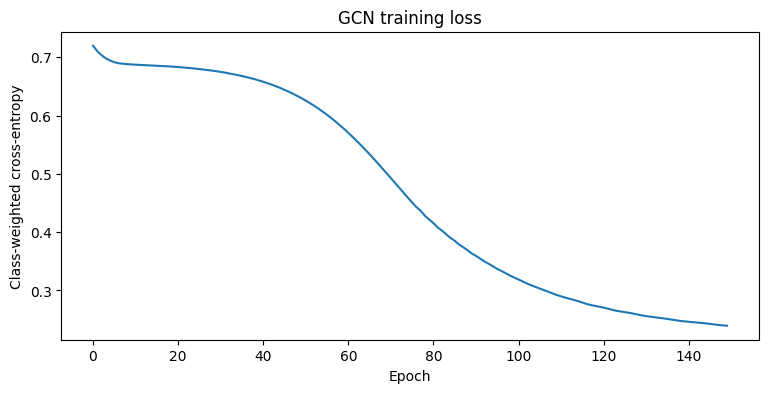

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(gnn_result.losses)
plt.xlabel("Epoch")
plt.ylabel("Class-weighted cross-entropy")
plt.title("GCN training loss")
plt.show()

## 8. Interpretation

- Negative curvature often identifies bridge-like or fragile market relationships.
- Positive curvature indicates more redundant local connectivity.
- Forman and Ollivier values are not numerically interchangeable; compare temporal patterns within one engine.
- The GNN is a comparison model trained on HMM labels, not independent ground truth.